# Monte Carlo Counterfactual Regret Minimization

This notebook studies Monte Carlo variants of Counterfactual Regret Minimization in Leduc Poker. The main comparison is between full-tree CFR, external-sampling MCCFR, and outcome-sampling MCCFR.

The sampling updates are written explicitly below. External sampling samples chance and opponent actions while evaluating all actions for the player being updated. Outcome sampling follows one terminal trajectory and uses importance weighting to correct for the sampled action.


In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cfr import VanillaCFR
from leduc_poker import LeducPoker
from regret_matching import regret_matching
from util import (
    collect_information_sets,
    expected_value,
    exploitability,
    format_strategy,
    strategy_from_arrays,
)

FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

efg = LeducPoker.efg(max_raises=2)
actions, _ = collect_information_sets(efg)
print("Nodes:", len(efg))
print("Information sets:", len(actions))


Nodes: 9451
Information sets: 288


## MCCFR Sampling Updates

Both algorithms use regret matching to form the current strategy at each information set. The difference is how much of the game tree is sampled before a regret update is made.


### External Sampling

For an update to player `i`, external sampling samples chance events and the opponent's actions. When the recursion reaches player `i`, it branches over every legal action, computes their sampled-world values, and updates regret by `action_values - node_value`.


In [2]:
class ExternalSamplingMCCFR:
    """External-sampling MCCFR written directly in the notebook.

    Regret matching and average-strategy formatting are imported helpers, but
    the Monte Carlo part is here: chance and opponent actions are sampled,
    while every action of the player being updated is evaluated.
    """

    def __init__(self, efg, seed=None):
        self.efg = efg
        self.rng = np.random.default_rng(seed)
        self.actions, _ = collect_information_sets(efg)
        self.regret = {
            info_set: np.zeros(len(actions))
            for info_set, actions in self.actions.items()
        }
        self.strategy_sum = {
            info_set: np.zeros(len(actions))
            for info_set, actions in self.actions.items()
        }
        self.iterations = 0
        self.node_visits = 0

    def current_strategy(self):
        return {
            info_set: {
                action: float(prob)
                for action, prob in zip(actions, regret_matching(self.regret[info_set]))
            }
            for info_set, actions in self.actions.items()
        }

    def average_strategy(self):
        return strategy_from_arrays(self.actions, self.strategy_sum)

    def train(self, iterations):
        for _ in range(iterations):
            for update_player in (0, 1):
                self._sample_tree("", update_player)
            self.iterations += 1

    def _sample_tree(self, node_id, update_player):
        self.node_visits += 1
        node = self.efg[node_id]

        if node["type"] == "TERMINAL":
            return float(node["utility"][update_player])

        if node["type"] == "CHANCE":
            outcomes = node["outcomes"]
            probabilities = np.array([prob for _, _, prob in outcomes], dtype=float)
            sampled = int(self.rng.choice(len(outcomes), p=probabilities))
            _, child, _ = outcomes[sampled]
            return self._sample_tree(child, update_player)

        player = node["player"]
        info_set = node["information_set"]
        legal_actions = [action for action, _ in node["actions"]]
        policy = regret_matching(self.regret[info_set])

        if player != update_player:
            self.strategy_sum[info_set] += policy
            sampled = int(self.rng.choice(len(legal_actions), p=policy))
            _, child = node["actions"][sampled]
            return self._sample_tree(child, update_player)

        action_values = np.zeros(len(legal_actions))
        node_value = 0.0
        for a, (_, child) in enumerate(node["actions"]):
            action_values[a] = self._sample_tree(child, update_player)
            node_value += policy[a] * action_values[a]

        self.regret[info_set] += action_values - node_value
        return float(node_value)


### Outcome Sampling and Importance Weighting

Outcome sampling follows one complete trajectory. Because only one action is observed at each decision node, the sampled action receives value `child_value / sampled_prob`; all unsampled actions receive zero sampled value. The regret update then multiplies by the reach-ratio `chance_opponent_reach / sample_reach`.


In [3]:
class OutcomeSamplingMCCFR:
    """Outcome-sampling MCCFR with epsilon exploration.

    One update samples a single terminal trajectory. The unsampled actions get
    zero sampled value, and the sampled action is divided by its sampling
    probability. This is the importance-sampling correction that keeps the
    one-trajectory estimate pointed at the full-tree counterfactual update.
    """

    def __init__(self, efg, seed=None, epsilon=0.6):
        self.efg = efg
        self.rng = np.random.default_rng(seed)
        self.epsilon = float(epsilon)
        self.actions, _ = collect_information_sets(efg)
        self.regret = {
            info_set: np.zeros(len(actions))
            for info_set, actions in self.actions.items()
        }
        self.strategy_sum = {
            info_set: np.zeros(len(actions))
            for info_set, actions in self.actions.items()
        }
        self.iterations = 0
        self.node_visits = 0

    def current_strategy(self):
        return {
            info_set: {
                action: float(prob)
                for action, prob in zip(actions, regret_matching(self.regret[info_set]))
            }
            for info_set, actions in self.actions.items()
        }

    def average_strategy(self):
        return strategy_from_arrays(self.actions, self.strategy_sum)

    def train(self, iterations):
        for _ in range(iterations):
            for update_player in (0, 1):
                self._sample_episode(
                    "",
                    update_player=update_player,
                    player_reach=1.0,
                    chance_opponent_reach=1.0,
                    sample_reach=1.0,
                )
            self.iterations += 1

    def _sample_episode(
        self,
        node_id,
        update_player,
        player_reach,
        chance_opponent_reach,
        sample_reach,
    ):
        self.node_visits += 1
        node = self.efg[node_id]

        if node["type"] == "TERMINAL":
            return float(node["utility"][update_player])

        if node["type"] == "CHANCE":
            outcomes = node["outcomes"]
            probabilities = np.array([prob for _, _, prob in outcomes], dtype=float)
            sampled = int(self.rng.choice(len(outcomes), p=probabilities))
            _, child, chance_prob = outcomes[sampled]
            return self._sample_episode(
                child,
                update_player,
                player_reach,
                chance_opponent_reach * chance_prob,
                sample_reach * chance_prob,
            )

        player = node["player"]
        info_set = node["information_set"]
        legal_actions = [action for action, _ in node["actions"]]
        policy = regret_matching(self.regret[info_set])

        if player == update_player:
            uniform = np.full(len(legal_actions), 1.0 / len(legal_actions))
            sample_policy = self.epsilon * uniform + (1.0 - self.epsilon) * policy
        else:
            sample_policy = policy

        sampled = int(self.rng.choice(len(legal_actions), p=sample_policy))
        sampled_prob = float(sample_policy[sampled])
        _, child = node["actions"][sampled]

        if player == update_player:
            next_player_reach = player_reach * float(policy[sampled])
            next_chance_opponent_reach = chance_opponent_reach
        else:
            next_player_reach = player_reach
            next_chance_opponent_reach = chance_opponent_reach * float(policy[sampled])

        child_value = self._sample_episode(
            child,
            update_player,
            next_player_reach,
            next_chance_opponent_reach,
            sample_reach * sampled_prob,
        )

        sampled_action_values = np.zeros(len(legal_actions))
        sampled_action_values[sampled] = child_value / sampled_prob
        node_value_estimate = float(policy @ sampled_action_values)

        if player == update_player:
            regret_weight = chance_opponent_reach / sample_reach
            average_weight = player_reach / sample_reach
            self.regret[info_set] += regret_weight * (
                sampled_action_values - node_value_estimate
            )
            self.strategy_sum[info_set] += average_weight * policy

        return node_value_estimate


## Training Helpers

In [4]:
def run_cfr(checkpoints):
    trainer = VanillaCFR(efg)
    rows = []
    previous = 0
    start = time.perf_counter()

    for step in checkpoints:
        trainer.train(int(step - previous))
        previous = int(step)
        strategy = trainer.average_strategy()
        rows.append(
            {
                "algorithm": "CFR",
                "seed": 0,
                "iterations": trainer.iterations,
                "node_visits": trainer.node_visits,
                "seconds": time.perf_counter() - start,
                "value": expected_value(efg, strategy),
                "exploitability": exploitability(efg, strategy),
            }
        )

    return trainer, pd.DataFrame(rows)


def run_external_sampling(checkpoints, seeds):
    rows = []
    trainers = []

    for seed in seeds:
        trainer = ExternalSamplingMCCFR(efg, seed=seed)
        trainers.append(trainer)
        previous = 0
        start = time.perf_counter()

        for step in checkpoints:
            trainer.train(int(step - previous))
            previous = int(step)
            strategy = trainer.average_strategy()
            rows.append(
                {
                    "algorithm": "External Sampling MCCFR",
                    "seed": seed,
                    "iterations": trainer.iterations,
                    "node_visits": trainer.node_visits,
                    "seconds": time.perf_counter() - start,
                    "value": expected_value(efg, strategy),
                    "exploitability": exploitability(efg, strategy),
                }
            )

    return trainers, pd.DataFrame(rows)


def run_outcome_sampling(checkpoints, seeds, epsilon=0.6):
    rows = []
    trainers = []

    for seed in seeds:
        trainer = OutcomeSamplingMCCFR(efg, seed=seed, epsilon=epsilon)
        trainers.append(trainer)
        previous = 0
        start = time.perf_counter()

        for step in checkpoints:
            trainer.train(int(step - previous))
            previous = int(step)
            strategy = trainer.average_strategy()
            rows.append(
                {
                    "algorithm": "Outcome Sampling MCCFR",
                    "seed": seed,
                    "iterations": trainer.iterations,
                    "node_visits": trainer.node_visits,
                    "seconds": time.perf_counter() - start,
                    "value": expected_value(efg, strategy),
                    "exploitability": exploitability(efg, strategy),
                }
            )

    return trainers, pd.DataFrame(rows)


def summarize(df):
    return (
        df.groupby(["algorithm", "iterations"], as_index=False)
        .agg(
            exploitability=("exploitability", "mean"),
            exploitability_std=("exploitability", "std"),
            value=("value", "mean"),
            node_visits=("node_visits", "mean"),
            seconds=("seconds", "mean"),
        )
        .fillna(0.0)
    )

## Run Experiments

In [5]:
cfr_checkpoints = np.unique(np.round(np.geomspace(1, 500, 14)).astype(int))
external_checkpoints = np.unique(np.round(np.geomspace(100, 100_000, 18)).astype(int))
outcome_checkpoints = np.unique(np.round(np.geomspace(1_000, 300_000, 18)).astype(int))
seeds = [0, 1, 2]

cfr_trainer, cfr_df = run_cfr(cfr_checkpoints)
external_trainers, external_df = run_external_sampling(external_checkpoints, seeds)
outcome_trainers, outcome_df = run_outcome_sampling(outcome_checkpoints, seeds, epsilon=0.6)

results = pd.concat([cfr_df, external_df, outcome_df], ignore_index=True)
summary = summarize(results)
summary.tail()

,algorithm,iterations,exploitability,exploitability_std,value,node_visits,seconds
45,Outcome Sampling MCCFR,78392,0.391268,0.061861,-0.094948,1.100063e+06,9.381816
46,Outcome Sampling MCCFR,109643,0.348493,0.135239,-0.100129,1.523781e+06,12.889108
47,Outcome Sampling MCCFR,153354,0.327721,0.116530,-0.089730,2.122980e+06,17.928516
48,Outcome Sampling MCCFR,214491,0.299955,0.065278,-0.094274,2.963125e+06,24.949997
49,Outcome Sampling MCCFR,300000,0.237494,0.064574,-0.093453,4.126712e+06,34.642272


In [6]:
final = summary.sort_values(["algorithm", "iterations"]).groupby("algorithm").tail(1)
final[["algorithm", "iterations", "value", "exploitability", "node_visits", "seconds"]]

,algorithm,iterations,value,exploitability,node_visits,seconds
13,CFR,500,-0.091170,0.030586,9.451000e+06,26.249651
31,External Sampling MCCFR,100000,-0.088230,0.041565,4.226681e+06,18.523189
49,Outcome Sampling MCCFR,300000,-0.093453,0.237494,4.126712e+06,34.642272


In [7]:
print("CFR nodes per iteration:", cfr_trainer.node_visits / cfr_trainer.iterations)
print("External sampling nodes per iteration, seed 0:", external_trainers[0].node_visits / external_trainers[0].iterations)
print("Outcome sampling nodes per iteration, seed 0:", outcome_trainers[0].node_visits / outcome_trainers[0].iterations)

print("\nSelected external-sampling average strategy entries, seed 0")
strategy = format_strategy(external_trainers[0].average_strategy(), digits=3)
for info_set in list(strategy)[:8]:
    print(info_set, strategy[info_set])

CFR nodes per iteration: 18902.0
External sampling nodes per iteration, seed 0: 42.63397
Outcome sampling nodes per iteration, seed 0: 13.693733333333334

Selected external-sampling average strategy entries, seed 0
P0|card=J|pub=-|r=0|h0=-|h1=-|cur=- {'check': 0.927, 'bet': 0.073}
P0|card=J|pub=-|r=0|h0=bet.raise|h1=-|cur=bet.raise {'fold': 0.001, 'call': 0.999}
P0|card=J|pub=-|r=0|h0=check.bet|h1=-|cur=check.bet {'fold': 0.927, 'call': 0.054, 'raise': 0.02}
P0|card=J|pub=J|r=1|h0=bet.call|h1=-|cur=- {'check': 0.341, 'bet': 0.659}
P0|card=J|pub=J|r=1|h0=bet.call|h1=bet.raise|cur=bet.raise {'fold': 0.003, 'call': 0.997}
P0|card=J|pub=J|r=1|h0=bet.call|h1=check.bet|cur=check.bet {'fold': 0.0, 'call': 0.0, 'raise': 1.0}
P0|card=J|pub=J|r=1|h0=bet.raise.call|h1=-|cur=- {'check': 0.018, 'bet': 0.982}
P0|card=J|pub=J|r=1|h0=bet.raise.call|h1=bet.raise|cur=bet.raise {'fold': 0.0, 'call': 1.0}


## Plots

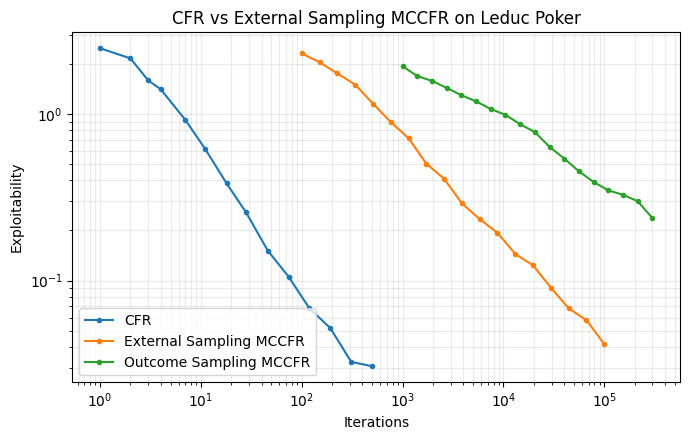

In [8]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("iterations")
    ax.plot(group["iterations"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations")
ax.set_ylabel("Exploitability")
ax.set_title("CFR vs External Sampling MCCFR on Leduc Poker")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "leduc_cfr_vs_external_sampling_mccfr.png", dpi=200)
plt.show()

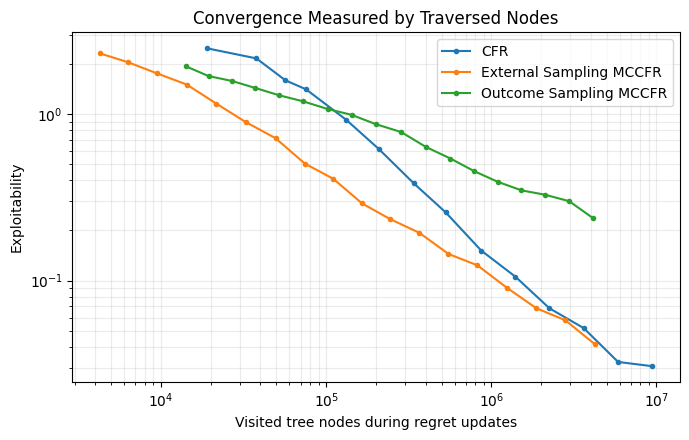

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("node_visits")
    ax.plot(group["node_visits"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Visited tree nodes during regret updates")
ax.set_ylabel("Exploitability")
ax.set_title("Convergence Measured by Traversed Nodes")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "leduc_mccfr_nodes.png", dpi=200)
plt.show()

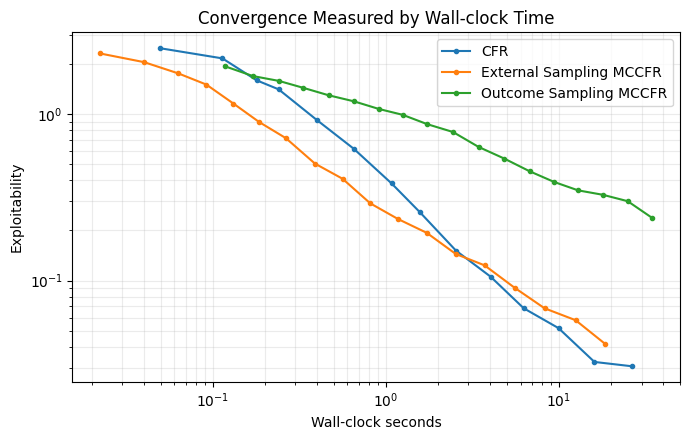

In [10]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("seconds")
    ax.plot(group["seconds"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Wall-clock seconds")
ax.set_ylabel("Exploitability")
ax.set_title("Convergence Measured by Wall-clock Time")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "leduc_mccfr_seconds.png", dpi=200)
plt.show()